# Model Training
#### This notebook will have the tokenizer, create vocabulary and transformer settings

In [2]:
# Data manipulation
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Hugging Face Tokenizers library
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Progress bar
from tqdm.auto import tqdm

# Reproducibility
import random

Matplotlib is building the font cache; this may take a moment.
/Users/macmini/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set a fixed random seed to make the experiment reproducible.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Select the best available device:
# CUDA for NVIDIA GPUs
# MPS for Apple Silicon Macs
# CPU otherwise

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [4]:
splits = {'train': 'train.csv', 'test': '**/test[-._ 0-9]*'}
df = pl.read_csv('hf://datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge/' + splits['train'])

In [5]:
df_new = (
    df
    .with_columns(
        pl.when(
            (pl.col("toxic") == 1) |
            (pl.col("severe_toxic") == 1) |
            (pl.col("insult") == 1) |
            (pl.col("identity_hate") == 1) |
            (pl.col("obscene") == 1) |
            (pl.col("threat") == 1)
        )
        .then(1)
        .otherwise(0)
        .alias("label")
    )
    .select([
        "id",
        "comment_text",
        "label"
    ])
)

In [6]:
# Remove rows with missing text or missing labels.
# Also remove empty comments.

df_model = (
    df_new
    .drop_nulls(["comment_text", "label"])
    .filter(
        pl.col("comment_text")
        .str.strip_chars()
        .str.len_chars() > 0
    )
)

print("Original rows:", len(df_new))
print("Clean rows:", len(df_model))

Original rows: 159571
Clean rows: 159571


### Train / Validation / Test split

In [7]:
# Convert Polars columns into Python lists.
# These lists will be used by scikit-learn for dataset splitting.

texts = df_model["comment_text"].to_list()
labels = df_model["label"].to_list()

print("Number of comments:", len(texts))
print("Number of labels:", len(labels))

print("\nExample comment:")
print(texts[0])

print("\nLabel:")
print(labels[0])

Number of comments: 159571
Number of labels: 159571

Example comment:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Label:
0


In [8]:
# First split:
# 80% training
# 20% temporary dataset
#
# Stratification preserves the class distribution.

X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

# Split the remaining 20% equally:
#
# 10% validation
# 10% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 127656
Validation samples: 15957
Test samples: 15958


### Tokenizer

In [9]:
# The tokenizer learns how to split text,
# but it does NOT learn the semantic meaning of words.

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

# Initially split text based on whitespace.
tokenizer.pre_tokenizer = Whitespace()

### Cell 10 — Configure the tokenizer trainer

In [10]:
special_tokens = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]"
]

#Max vocab

VOCAB_SIZE = 30000

trainer = BpeTrainer(
    vocab_size = VOCAB_SIZE,
    special_tokens = special_tokens,
    min_frequency = 2
)

In [11]:
tokenizer.train_from_iterator(X_train, trainer=trainer)

print("Vocabulary size:", tokenizer.get_vocab_size())




Vocabulary size: 30000


In [12]:
PAD_ID = tokenizer.token_to_id("[PAD]")
UNK_ID = tokenizer.token_to_id("[UNK]")
CLS_ID = tokenizer.token_to_id("[CLS]")
SEP_ID = tokenizer.token_to_id("[SEP]")

print("PAD ID:", PAD_ID)
print("UNK ID:", UNK_ID)
print("CLS ID:", CLS_ID)
print("SEP ID:", SEP_ID)

PAD ID: 0
UNK ID: 1
CLS ID: 2
SEP ID: 3


In [13]:
# Automatically transform:
#
# "this is a comment"
#
# into:
#
# [CLS] this is a comment [SEP]

tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    special_tokens=[
        ("[CLS]", CLS_ID),
        ("[SEP]", SEP_ID)
    ]
)

# Maximum sequence length.
#
# Longer comments will be truncated.
# Shorter comments will be padded with [PAD].

MAX_LEN = 128

tokenizer.enable_truncation(
    max_length=MAX_LEN
)

tokenizer.enable_padding(
    length=MAX_LEN,
    pad_id=PAD_ID,
    pad_token="[PAD]"
)

In [14]:
# Test the tokenizer with a simple example.

example_text = "You are a really stupid person"

encoded = tokenizer.encode(
    example_text
)

print("Original text:")
print(example_text)

print("\nTokens:")
print(encoded.tokens)

print("\nToken IDs:")
print(encoded.ids)

print("\nAttention mask:")
print(encoded.attention_mask)

Original text:
You are a really stupid person

Tokens:
['[CLS]', 'You', 'are', 'a', 'really', 'stupid', 'person', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PA

### Dataset

In [15]:
class ToxicityDataset(Dataset):

    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        #Tokenize the comment
        encoded = self.tokenizer.encode(text)

        #Convert id into tensor
        input_ids = torch.tensor(
            encoded.ids,
            dtype=torch.long
        )

        #Convert attention mask to pytorch tensor
        attention_mask = torch.tensor(encoded.attention_mask, dtype=torch.long)

        #convert label to tensor
        label = torch.tensor(label,dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label
        }

In [16]:
train_dataset = ToxicityDataset(
    X_train,
    y_train,
    tokenizer
)

val_dataset = ToxicityDataset(
    X_val,
    y_val,
    tokenizer
)

test_dataset = ToxicityDataset(
    X_test,
    y_test,
    tokenizer
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 127656
Validation: 15957
Test: 15958


In [17]:
# Inspect one tokenized example.

sample = train_dataset[0]

print("Input IDs shape:")
print(sample["input_ids"].shape)

print("\nInput IDs:")
print(sample["input_ids"])

print("\nAttention mask:")
print(sample["attention_mask"])

print("\nLabel:")
print(sample["label"])

Input IDs shape:
torch.Size([128])

Input IDs:
tensor([    2, 12033,  2634,  2253,  2219,  3306,    17,  4520,  3533,  2303,
         2401,     4,  3264,    29,  4885,    15,  2948,  4434,  3578,    11,
         2873,    12,     3,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,   

### DataLoaders

In [18]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches:", len(train_loader), "\n")
print("Number of validation batches:", len(val_loader), "\n")
print("Number of test batches:", len(test_loader))

Number of training batches: 3990 

Number of validation batches: 499 

Number of test batches: 499


### Transformer Arquitecture

In [19]:
# Hyperparameters

EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 6
DIM_FEEDFORWARD = 1028
DROPOUT = 0.1
NUM_CLASSES = 2
VOCAB_SIZE = tokenizer.get_vocab_size()
MAX_LEN = 128

In [20]:
class TransformerClassifier(nn.Module):

    def __init__(self, vocab_size, num_classes, pad_id, max_len=128, embed_dim=256, num_heads=8, num_layers=6, dim_feedforward=1028, dropout=0.1):
        super().__init__()

        #Token to embedding layer
        self.token_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_id
        )

        #Positional embedding layer
        self.positional_embedding = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=embed_dim
        )

        #Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        #Transformer blocks
        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers = num_layers
        )

        #Dropout
        self.dropout = nn.Dropout(dropout)

        #Classification Layer
        self.classifier = nn.Linear(embed_dim, num_classes)



    def forward(self, input_ids, attention_mask):
        
        batch_size, seq_len = input_ids.shape

        #Create postitions ids

        positions = torch.arange(
            seq_len, 
            device=input_ids.device
        )

        positions = (
            positions
            .unsqueeze(0)
            .expand(batch_size, seq_len)
        )

        #Token embeddings
        token_embeddings = self.token_embedding(input_ids)

        #positional embeddings
        positional_embeddings = self.positional_embedding(positions)

        #combine token + position 
        x = (token_embeddings + positional_embeddings)

        #CREATE Padding mask 
        # PyTorch Transformer expects:
        
        # True  = ignore this token
        # False = use this token

        padding_mask = (attention_mask ==0)

        x = self.transformer(
            x,
            src_key_padding_mask=padding_mask
        )

        # EXTRACT THE CLS REPRESENTATION
       
       # [CLS] is always the first token.
        #
        # Before:
        #
        # (batch_size, sequence_length, d_model)
        #
        # After:
        #
        # (batch_size, d_model)

        cls_output = x[:, 0, :]

        cls_output = self.dropout(
            cls_output)

        logits = self.classifier(cls_output)

        return logits



In [21]:
# Create the Transformer classifier.

model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
)

# Move the model to the selected device.

model = model.to(device)

print(model)

/Users/macmini/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TransformerClassifier(
  (token_embedding): Embedding(30000, 256, padding_idx=0)
  (positional_embedding): Embedding(128, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1028, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1028, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)


In [22]:
# Count model parameters.

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: {total_parameters:,}"
)

print(
    f"Trainable parameters: {trainable_parameters:,}"
)

Total parameters: 12,464,154
Trainable parameters: 12,464,154


### Calculate class weights

In [23]:
# Count how many training examples belong to each class.

class_counts = np.bincount(
    y_train,
    minlength=2
)

# Compute inverse-frequency weights.
#
# A minority class receives a higher loss weight.

class_weights = (
    len(y_train)
    /
    (
        len(class_counts)
        * class_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
[114676  12980]

Class weights:
tensor([0.5566, 4.9174], device='mps:0')


### Loss & Optimizer

In [24]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

### Training function

In [25]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device
):

    # Enable training mode.

    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    progress_bar = tqdm(
        data_loader,
        desc="Training"
    )

    for batch in progress_bar:

        # Move data to GPU / MPS / CPU.

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        # Remove gradients from the previous iteration.

        optimizer.zero_grad()

        # Forward pass.

        logits = model(
            input_ids,
            attention_mask
        )

        # Calculate classification loss.

        loss = criterion(
            logits,
            labels
        )

        # Backpropagation.

        loss.backward()

        # Prevent exploding gradients.

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update all trainable parameters.

        optimizer.step()

        # Accumulate loss.

        total_loss += loss.item()

        # Convert logits into predicted classes.

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_examples += (
            labels.size(0)
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_loss = (
        total_loss
        / len(data_loader)
    )

    accuracy = (
        correct_predictions
        / total_examples
    )

    return average_loss, accuracy

In [26]:
def evaluate(
    model,
    data_loader,
    criterion,
    device
):

    # Disable training-specific behavior such as dropout.

    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    all_predictions = []
    all_labels = []

    # Disable gradient calculations during evaluation.

    with torch.no_grad():

        for batch in tqdm(
            data_loader,
            desc="Evaluating"
        ):

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            # Forward pass.

            logits = model(
                input_ids,
                attention_mask
            )

            # Calculate loss.

            loss = criterion(
                logits,
                labels
            )

            # Get predicted class.

            predictions = torch.argmax(
                logits,
                dim=1
            )

            total_loss += loss.item()

            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_examples += (
                labels.size(0)
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )

    average_loss = (
        total_loss
        / len(data_loader)
    )

    accuracy = (
        correct_predictions
        / total_examples
    )

    return (
        average_loss,
        accuracy,
        all_predictions,
        all_labels
    )

In [27]:
# Number of complete passes through the training dataset.

EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print("-" * 50)

    # ----------------------
    # TRAINING
    # ----------------------

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device=device
    )

    # ----------------------
    # VALIDATION
    # ----------------------

    val_loss, val_accuracy, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # Save metrics.

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    # Print epoch results.

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.4f}"
    )


Epoch 1/10
--------------------------------------------------


Evaluating: 100%|██████████| 499/499 [00:17<00:00, 28.04it/s]


Train Loss: 0.5567 | Train Accuracy: 0.7624
Validation Loss: 0.4591 | Validation Accuracy: 0.9093

Epoch 2/10
--------------------------------------------------


Evaluating: 100%|██████████| 499/499 [00:17<00:00, 28.07it/s]


Train Loss: 0.4168 | Train Accuracy: 0.8770
Validation Loss: 0.4546 | Validation Accuracy: 0.9216

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.4057 | Train Accuracy: 0.8804
Validation Loss: 0.4907 | Validation Accuracy: 0.9232

Epoch 9/10
--------------------------------------------------


Evaluating: 100%|██████████| 499/499 [00:17<00:00, 28.01it/s]


Train Loss: 0.4084 | Train Accuracy: 0.8823
Validation Loss: 0.4093 | Validation Accuracy: 0.8807

Epoch 10/10
--------------------------------------------------


Evaluating: 100%|██████████| 499/499 [00:17<00:00, 28.05it/s]

Train Loss: 0.4141 | Train Accuracy: 0.8803
Validation Loss: 0.4545 | Validation Accuracy: 0.9168


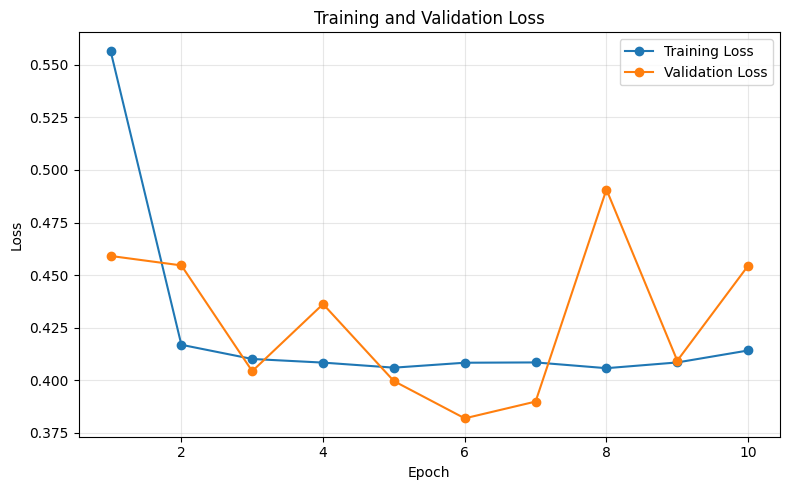

In [28]:
# Plot training and validation loss.

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

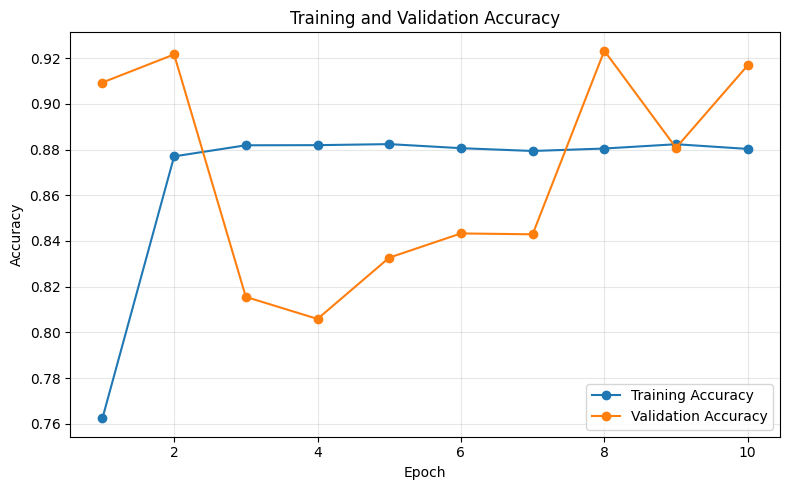

In [29]:
# Plot training and validation accuracy.

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Evaluate the final model using the unseen test dataset.

(
    test_loss,
    test_accuracy,
    test_predictions,
    test_labels
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

Evaluating: 100%|██████████| 499/499 [00:17<00:00, 28.24it/s]

Test Loss: 0.4298
Test Accuracy: 0.9219


In [31]:
# Display precision, recall, and F1-score.

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Non-toxic",
            "Toxic"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

   Non-toxic     0.9583    0.9546    0.9565     14335
       Toxic     0.6123    0.6334    0.6227      1623

    accuracy                         0.9219     15958
   macro avg     0.7853    0.7940    0.7896     15958
weighted avg     0.9231    0.9219    0.9225     15958



In [32]:
# Create the confusion matrix.

cm = confusion_matrix(
    test_labels,
    test_predictions
)

print(cm)

[[13684   651]
 [  595  1028]]


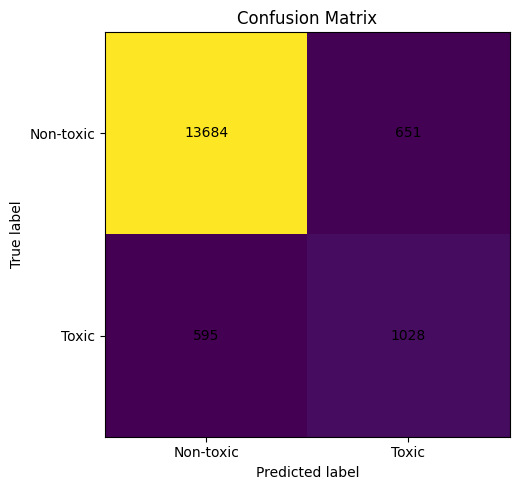

In [33]:
# Plot the confusion matrix using Matplotlib.

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    cm
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Non-toxic", "Toxic"]
)

ax.set_yticklabels(
    ["Non-toxic", "Toxic"]
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_title(
    "Confusion Matrix"
)

# Display the numerical value inside each cell.

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [34]:
def predict_text(
    text,
    model,
    tokenizer,
    device
):
    """
    Predict whether a comment is toxic or non-toxic.

    Returns:
        predicted_class
        class probabilities
    """

    model.eval()

    # Tokenize the text.

    encoded = tokenizer.encode(
        text
    )

    # Add batch dimension.

    input_ids = torch.tensor(
        encoded.ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    attention_mask = torch.tensor(
        encoded.attention_mask,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        # Get raw logits.

        logits = model(
            input_ids,
            attention_mask
        )

        # Convert logits into probabilities.

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        # Select the class with the highest probability.

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

    probabilities = (
        probabilities
        .cpu()
        .numpy()[0]
    )

    return (
        predicted_class,
        probabilities
    )

In [35]:
text = "You are such an idiot"

prediction, probabilities = predict_text(
    text,
    model,
    tokenizer,
    device
)

print("Text:")
print(text)

print("\nPrediction:")

if prediction == 0:
    print("Non-toxic")
else:
    print("Toxic")

print("\nProbabilities:")

print(
    f"Non-toxic: {probabilities[0]:.4f}"
)

print(
    f"Toxic:     {probabilities[1]:.4f}"
)

Text:
You are such an idiot

Prediction:
Toxic

Probabilities:
Non-toxic: 0.0624
Toxic:     0.9376


In [36]:
# Save the trained Transformer parameters.

from pathlib import Path

# Support running from the project root or the notebooks folder.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

model_dir = project_root / "model"
model_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    model.state_dict(),
    model_dir / "toxicity_transformer.pt"
)

print(
    f"Model saved to: {model_dir / 'toxicity_transformer.pt'}"
)

Model saved to: /Users/macmini/Desktop/Data_Science/Transformer_MacBook01/TransformerModel_CommentClassification/model/toxicity_transformer.pt


In [37]:
# Save the trained BPE tokenizer.

tokenizer.save(
    str(model_dir / "toxicity_tokenizer.json")
)

print(
    f"Tokenizer saved to: {model_dir / 'toxicity_tokenizer.json'}"
)

Tokenizer saved to: /Users/macmini/Desktop/Data_Science/Transformer_MacBook01/TransformerModel_CommentClassification/model/toxicity_tokenizer.json
